# Etape 2 — Analyse exploratoire et visualisation
## Projet House Prices — Estimation du prix de vente d'un logement

**Objectif de ce notebook :** aller au-dela des statistiques univariees deja
vues a l'etape 1 (distribution de `SalePrice`, valeurs manquantes) et
explorer les **relations entre les variables et le prix de vente**, afin de
degager des premieres intuitions qui orienteront le feature engineering
(etape 3) et le choix des modeles (etape 4+).

Questions auxquelles ce notebook repond :
1. Comment le prix de vente est-il distribue, et avec quels prix extremes ?
2. La surface habitable est-elle liee au prix, et de facon lineaire ?
3. La qualite percue du logement (`OverallQual`, `KitchenQual`...) influence-t-elle le prix ?
4. Le quartier (`Neighborhood`) est-il un facteur de prix important ?
5. L'age et l'annee de vente ont-ils un effet sur le prix ?
6. Quelles variables numeriques sont les plus correlees a `SalePrice`, et entre elles (redondance) ?


## 1. Import des librairies et chargement des donnees

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

# --- Detection automatique de l'environnement (local vs Kaggle) -------------
# Objectif : ne JAMAIS avoir a modifier les chemins a la main selon qu'on
# execute ce notebook en local ou dans un Kaggle Notebook. Le meme fichier
# .ipynb tourne tel quel dans les deux cas.
#
# Sur Kaggle, la profondeur exacte sous /kaggle/input varie selon la version
# de l'interface (parfois /kaggle/input/<dataset>/..., parfois
# /kaggle/input/datasets/<dataset>/...) : plutot que de deviner, on
# RECHERCHE directement House_Prices.csv dans toute l'arborescence.
if os.path.exists('/kaggle/input'):
    _dataset_dir = None
    for _root, _dirs, _files in os.walk('/kaggle/input'):
        if 'House_Prices.csv' in _files:
            # _root est .../data/raw -> la racine du dataset est 2 niveaux au-dessus
            _dataset_dir = os.path.dirname(os.path.dirname(_root))
            break

    if _dataset_dir is None:
        raise FileNotFoundError(
            "House_Prices.csv introuvable sous /kaggle/input. Verifie que le "
            "Dataset 'house-prices-project' est bien attache (panneau de droite "
            "-> Input -> Add Input), et que la structure data/raw/House_Prices.csv "
            "a ete preservee lors de l'upload."
        )

    BASE_DATA = f'{_dataset_dir}/data'      # lecture seule (donnees brutes)
    BASE_SRC = f'{_dataset_dir}/src'        # lecture seule (src/preprocessing.py)
    OUTPUT_DIR = '/kaggle/working'          # seul dossier inscriptible sur Kaggle
    print(f"Environnement Kaggle detecte -> dataset = {_dataset_dir}")
else:
    BASE_DATA = '../data'
    BASE_SRC = '..'
    OUTPUT_DIR = '..'
    print("Environnement local detecte")

sys.path.append(BASE_SRC)

pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Le CSV nettoye est lu depuis OUTPUT_DIR (ecrit par le notebook 01 dans la
# meme session), pas depuis BASE_DATA (qui est en lecture seule sur Kaggle).
PROCESSED_PATH = f'{OUTPUT_DIR}/data/processed/house_prices_clean.csv'
RAW_PATH = f'{BASE_DATA}/raw/House_Prices.csv'


Environnement local detecte


**Attention lors du rechargement du CSV :** le fichier `house_prices_clean.csv`
produit a l'etape 1 contient la chaine de caracteres litterale `"None"`
comme categorie a part entiere (ex. `PoolQC = "None"` signifie "pas de
piscine", cf. etape 1 section 6.1). Or, `pandas.read_csv` traite par
defaut le texte `None` comme une valeur manquante et le convertit en `NaN`
a la lecture -- ce qui detruirait silencieusement l'information qu'on vient
justement de reconstruire. On desactive donc ce comportement par defaut et
on precise explicitement qu'une cellule **vide** (et seulement une cellule
vide) doit etre interpretee comme manquante.

In [2]:
import os

if os.path.exists(PROCESSED_PATH):
    df = pd.read_csv(PROCESSED_PATH, keep_default_na=False, na_values=[''])
    print(f"Donnees chargees depuis {PROCESSED_PATH}")
else:
    # Filet de securite : si le notebook 01 n'a pas encore ete (re)execute,
    # on reconstruit la meme version 'nettoyee non encodee' a partir du brut
    # en reutilisant les fonctions validees a l'etape 1.
    from src.preprocessing import load_data, basic_cleaning, fill_structural_missing, remove_outliers
    df = load_data(RAW_PATH)
    df = basic_cleaning(df)
    df = fill_structural_missing(df)
    df = remove_outliers(df)
    print("data/processed/house_prices_clean.csv introuvable -> regenere depuis le brut via src/preprocessing.py")

print("Dimensions :", df.shape)
missing_left = df.isnull().sum()
print("Colonnes avec de vraies valeurs manquantes restantes :", (missing_left > 0).sum())
df.head()


Donnees chargees depuis ../data/processed/house_prices_clean.csv
Dimensions : (1458, 80)
Colonnes avec de vraies valeurs manquantes restantes : 2


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,GarageAge
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,None,Attchd,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500.0,5.0
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500.0,31.0
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500.0,7.0
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000.0,8.0
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000.0,8.0


**Interpretation :** on retrouve les 2916 lignes et les colonnes non
encodees de l'etape 1 (outliers deja retires, absences d'equipement deja
codees en `"None"`/`0`). Les seules valeurs manquantes restantes sont les
"vraies" valeurs manquantes (`LotFrontage` et quelques colonnes a tres
faible cardinalite de NaN) : elles sont volontairement laissees telles
quelles ici, car leur imputation (mediane de quartier, mode) doit etre
apprise apres le split train/test -- c'est le role du `ColumnTransformer`
de `src/preprocessing.py`, pas de ce notebook d'exploration.

## 2. Distribution du prix de vente (`SalePrice`)

In [3]:
print(df['SalePrice'].describe().apply(lambda x: f"{x:,.0f}"))
print(f"\nSkewness : {df['SalePrice'].skew():.2f}")
print(f"Kurtosis : {df['SalePrice'].kurt():.2f}")


count      1,458
mean     180,933
std       79,495
min       34,900
25%      129,925
50%      163,000
75%      214,000
max      755,000
Name: SalePrice, dtype: str

Skewness : 1.88
Kurtosis : 6.52


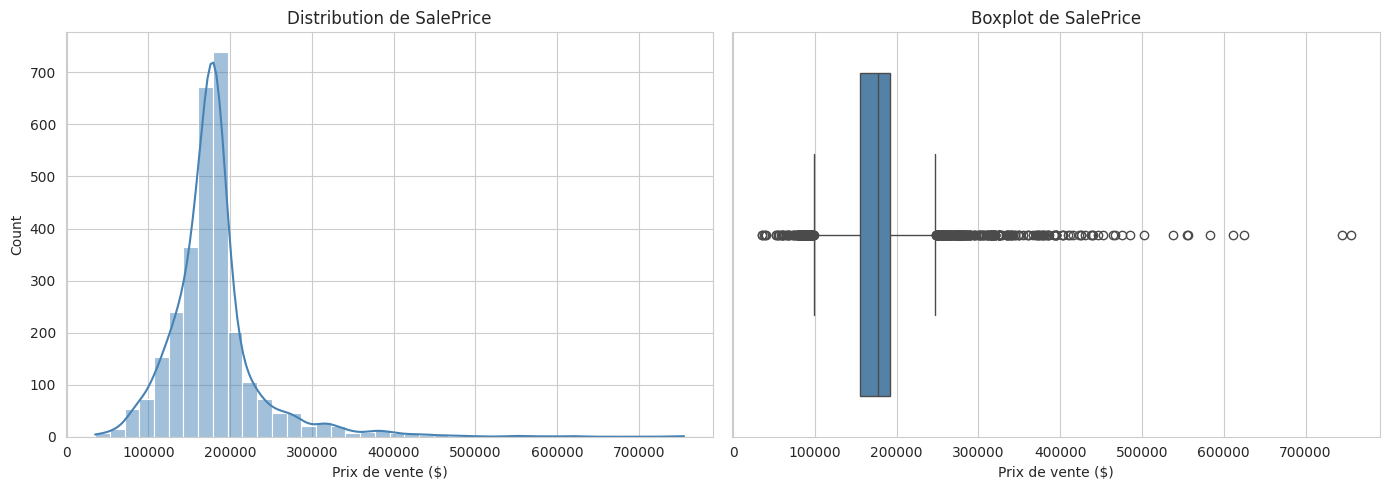

Bornes IQR : au-dela de 247,638 $ -> 236 logements (8.1%) consideres extremes (pas aberrants : ce sont des ventes hauts de gamme plausibles).


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='steelblue', bins=40)
axes[0].set_title('Distribution de SalePrice')
axes[0].set_xlabel('Prix de vente ($)')

sns.boxplot(x=df['SalePrice'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot de SalePrice')
axes[1].set_xlabel('Prix de vente ($)')

plt.tight_layout()
plt.show()

q1, q3 = df['SalePrice'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
n_extremes = (df['SalePrice'] > upper_fence).sum()
print(f"Bornes IQR : au-dela de {upper_fence:,.0f} $ -> {n_extremes} logements ({n_extremes/len(df)*100:.1f}%) consideres extremes (pas aberrants : ce sont des ventes hauts de gamme plausibles).")


**Interpretation :** confirmation de l'asymetrie a droite vue a l'etape 1
(skewness ~1.5) : la mediane des ventes se situe autour de 160 000 $, mais
une traine de logements haut de gamme (> ~340 000 $ selon la regle des 1.5
IQR) tire la moyenne vers le haut. Ce ne sont pas des valeurs aberrantes a
retirer -- contrairement au cas `GrLivArea > 4000 $ SalePrice < 300000`
deja traite -- simplement des logements premium coherents avec leurs
caracteristiques (on le verifiera dans les sections suivantes). Cela
confirme l'interet d'une transformation `log1p(SalePrice)` pour la cible
lors de la modelisation lineaire (decision actee a l'etape 1, appliquee a
l'etape 4).

## 3. Surface habitable vs prix

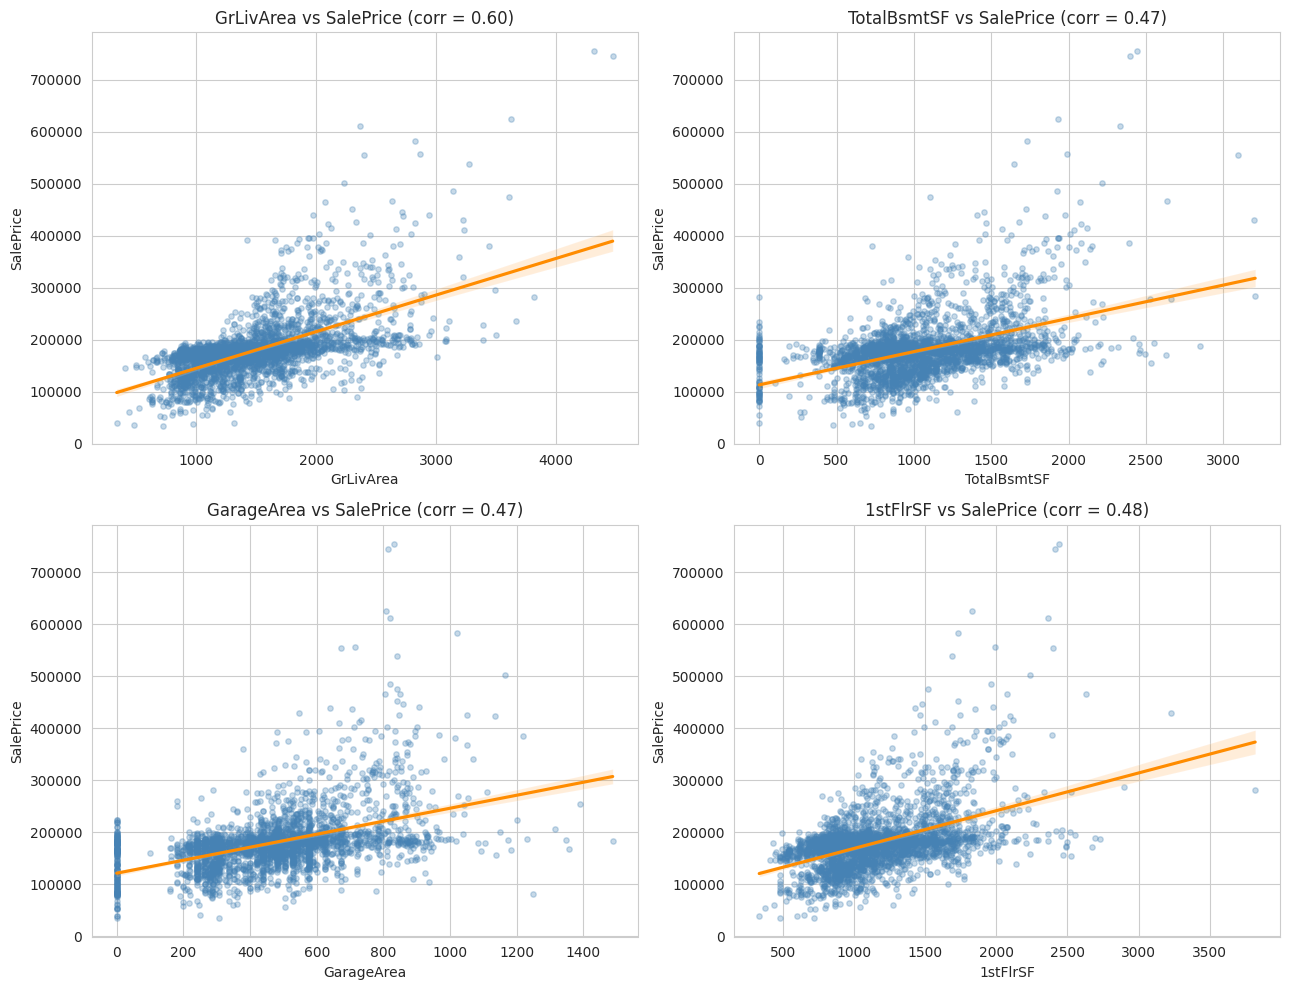

In [5]:
surface_cols = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', '1stFlrSF']

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

for ax, col in zip(axes, surface_cols):
    sns.regplot(x=df[col], y=df['SalePrice'], ax=ax,
                scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
                line_kws={'color': 'darkorange'})
    corr = df[col].corr(df['SalePrice'])
    ax.set_title(f'{col} vs SalePrice (corr = {corr:.2f})')

plt.tight_layout()
plt.show()


**Interpretation :** `GrLivArea` (surface habitable hors sous-sol) est la
surface la plus fortement et le plus lineairement liee au prix -- la droite
de regression suit bien le nuage de points. `TotalBsmtSF` et `GarageArea`
sont egalement correlees positivement mais avec plus de dispersion (un
logement peut ne pas avoir de sous-sol amenage ou de garage sans que cela
penalise autant le prix qu'une petite surface habitable). On note aussi
un etalement croissant de la variance avec la surface (heteroscedasticite)
: plus une maison est grande, plus la variabilite du prix autour de la
tendance augmente -- point a garder en tete pour le choix et l'evaluation
des modeles de regression.

## 4. Qualite percue vs prix

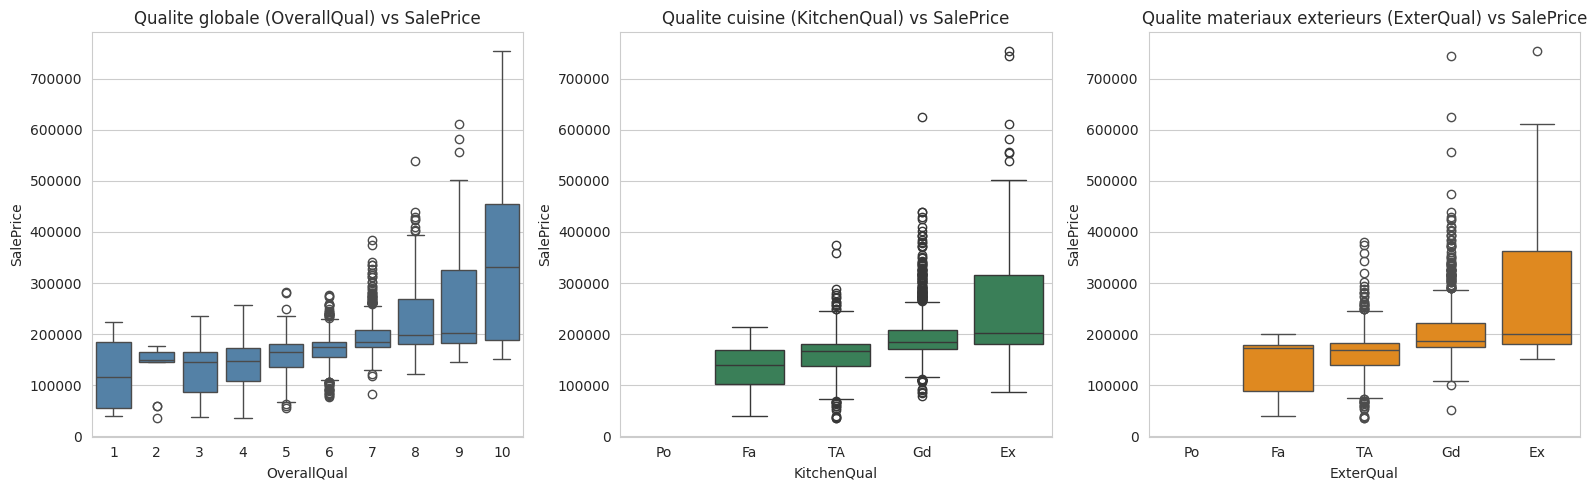

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x='OverallQual', y='SalePrice', data=df, ax=axes[0], color='steelblue')
axes[0].set_title('Qualite globale (OverallQual) vs SalePrice')

kitchen_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
sns.boxplot(x='KitchenQual', y='SalePrice', data=df, order=kitchen_order, ax=axes[1], color='seagreen')
axes[1].set_title('Qualite cuisine (KitchenQual) vs SalePrice')

sns.boxplot(x='ExterQual', y='SalePrice', data=df, order=kitchen_order, ax=axes[2], color='darkorange')
axes[2].set_title('Qualite materiaux exterieurs (ExterQual) vs SalePrice')

plt.tight_layout()
plt.show()


**Interpretation :** la relation entre `OverallQual` (note globale de 1
a 10) et `SalePrice` est nette, monotone, et quasi lineaire sur l'essentiel
de l'echelle -- c'est generalement la variable individuelle la plus
predictive de ce dataset. Les variables ordinales de qualite plus
specifiques (`KitchenQual`, `ExterQual`) suivent la meme logique : chaque
palier de qualite ('TA' -> 'Gd' -> 'Ex') correspond a un saut de prix
median net, avec peu de chevauchement entre boites -- ce qui valide a
posteriori le choix de les encoder en `OrdinalEncoder` (etape 1) plutot
qu'en one-hot, puisque l'ordre porte une vraie information monotone.

## 5. Prix par quartier (`Neighborhood`)

/tmp/ipykernel_138/1286183543.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


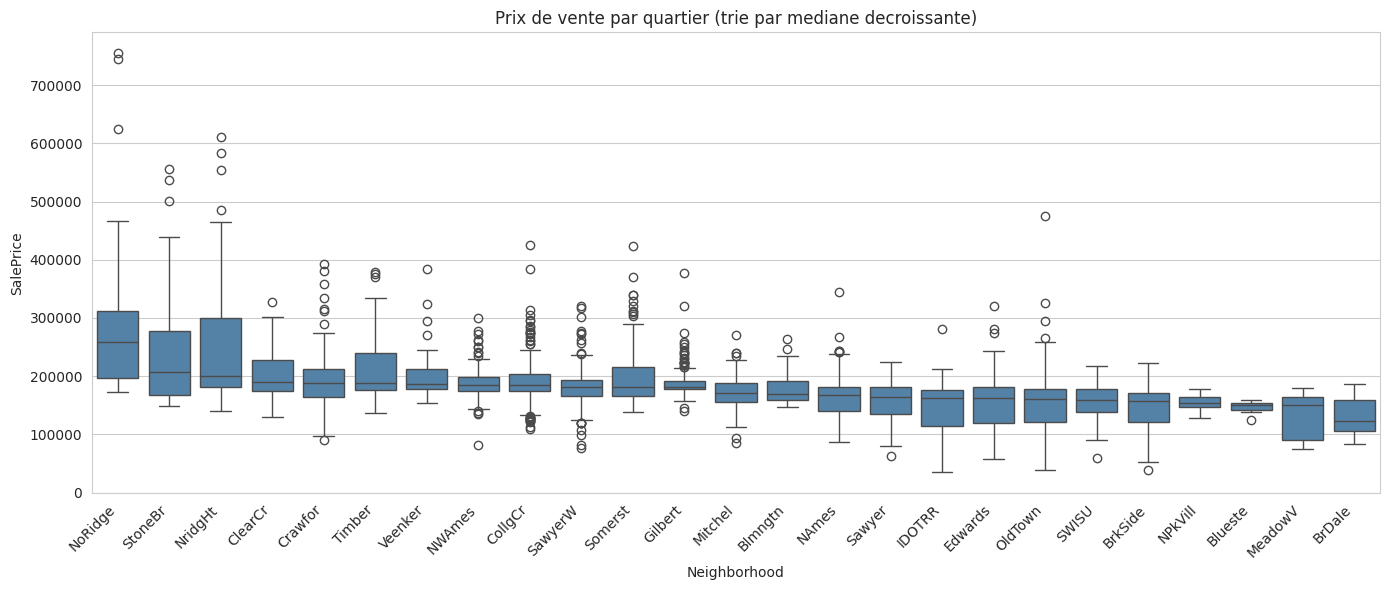

3 quartiers les plus chers (mediane) :
                     median  count
Neighborhood                      
NoRidge       258000.000000     71
StoneBr       207500.000000     51
NridgHt       200685.038665    166

3 quartiers les moins chers (mediane) :
                     median  count
Neighborhood                      
Blueste       150889.479488     10
MeadowV       150011.102062     37
BrDale        123750.000000     30


In [7]:
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df, order=order, ax=ax, color='steelblue')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Prix de vente par quartier (trie par mediane decroissante)')
plt.tight_layout()
plt.show()

neigh_summary = df.groupby('Neighborhood')['SalePrice'].agg(['median', 'count']).sort_values('median', ascending=False)
print("3 quartiers les plus chers (mediane) :")
print(neigh_summary.head(3))
print("\n3 quartiers les moins chers (mediane) :")
print(neigh_summary.tail(3))


**Interpretation :** le quartier a un effet tres marque sur le prix --
l'ecart de mediane entre le quartier le plus cher et le moins cher
represente plusieurs fois le prix median global, largement au-dela de ce
qu'expliquent la surface ou la qualite seules. C'est une variable
categorielle **nominale** a forte cardinalite (~25 quartiers) sans ordre
naturel : le choix du one-hot encoding (etape 1) est justifie, meme s'il
genere de nombreuses colonnes -- un encodage ordinal arbitraire aurait
introduit une fausse hierarchie entre quartiers.

## 6. Anciennete du logement vs prix

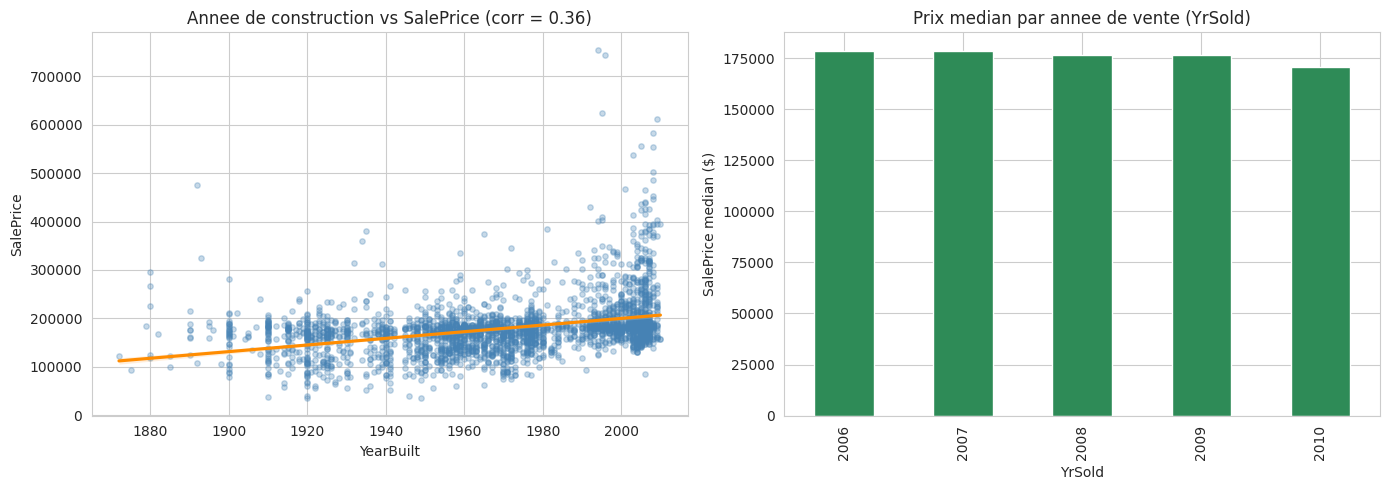

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(x=df['YearBuilt'], y=df['SalePrice'], ax=axes[0],
            scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
            line_kws={'color': 'darkorange'})
axes[0].set_title(f"Annee de construction vs SalePrice (corr = {df['YearBuilt'].corr(df['SalePrice']):.2f})")

yearly_median = df.groupby('YrSold')['SalePrice'].median()
yearly_median.plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Prix median par annee de vente (YrSold)')
axes[1].set_ylabel('SalePrice median ($)')

plt.tight_layout()
plt.show()


**Interpretation :** les logements plus recents se vendent en moyenne
plus cher, avec une relation positive mais moins lineaire et plus dispersee
que pour la surface (des maisons anciennes bien renovees restent
competitives, cf. `RemodAge`, deja identifiee comme feature interessante
pour l'etape 3). Le prix median par annee de vente (`YrSold`, 2006-2010)
est en revanche remarquablement stable -- coherent avec une fenetre
temporelle courte -- sans effet de tendance ou de crise immobiliere
marquant que le modele devrait absolument capturer.

## 7. Matrice de correlation des variables numeriques

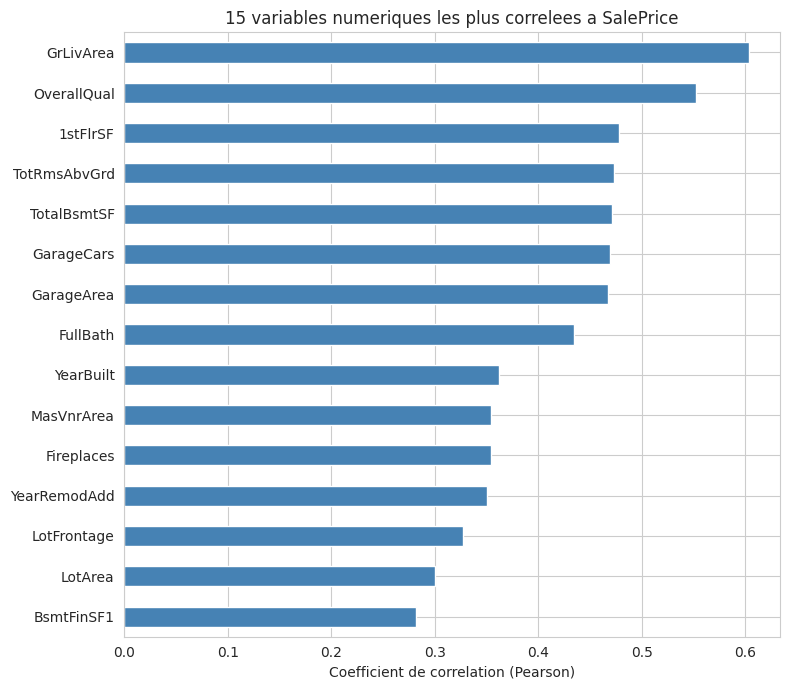

In [9]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

top_corr = corr_matrix['SalePrice'].drop('SalePrice').sort_values(key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 7))
top_corr.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('15 variables numeriques les plus correlees a SalePrice')
ax.set_xlabel('Coefficient de correlation (Pearson)')
plt.tight_layout()
plt.show()


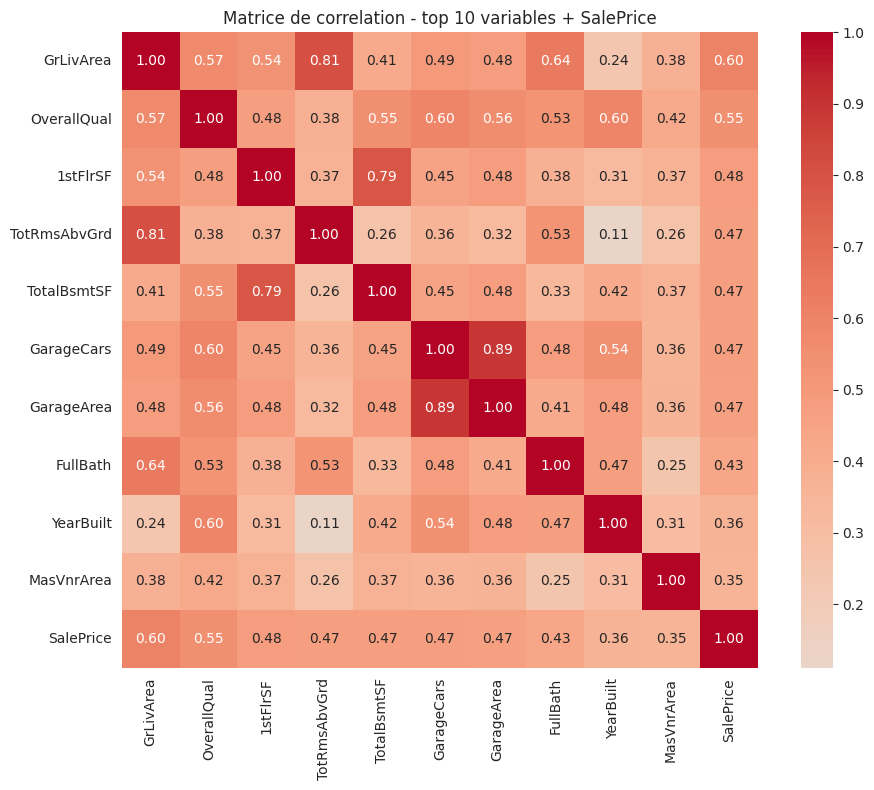

In [10]:
top_features = top_corr.index.tolist()[:10] + ['SalePrice']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(numeric_df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax)
ax.set_title('Matrice de correlation - top 10 variables + SalePrice')
plt.tight_layout()
plt.show()


**Interpretation :** `OverallQual` et `GrLivArea` dominent nettement le
classement des correlations avec `SalePrice`, suivies des variables de
garage (`GarageCars`, `GarageArea`) et de sous-sol (`TotalBsmtSF`,
`1stFlrSF`). On observe aussi une **forte colinearite entre certaines
variables explicatives elles-memes** (ex. `GarageCars` et `GarageArea`,
ou `TotalBsmtSF` et `1stFlrSF`) : elles portent une information largement
redondante. Ce n'est pas problematique pour les modeles a base d'arbres,
mais c'est un point de vigilance pour une regression lineaire/Ridge
(multicolinearite) -- a surveiller a l'etape 4, et un argument de plus en
faveur des variables agregees deja prevues pour l'etape 3 (`TotalSF`,
`TotalBath`), qui resument plusieurs surfaces correlees en une seule
feature plus synthetique.

## Conclusion de l'etape 2

- La variable cible `SalePrice` est asymetrique a droite, avec une traine
  de ventes haut de gamme plausibles (pas d'aberrations supplementaires a
  retirer au-dela de celles deja traitees a l'etape 1).
- La **surface habitable** (`GrLivArea` en tete) est liee de facon
  quasi-lineaire au prix, avec une variance croissante pour les grandes
  surfaces.
- La **qualite percue** (`OverallQual` en tete, puis les qualites
  specifiques comme `KitchenQual`) est le facteur individuel le plus
  discriminant, ce qui valide l'encodage ordinal choisi a l'etape 1.
- Le **quartier** (`Neighborhood`) cree des ecarts de prix tres importants,
  independamment de la surface ou de la qualite -- confirmant le choix du
  one-hot encoding pour cette variable nominale a forte cardinalite.
- L'**anciennete** (age, annee de construction) joue un role, mais plus
  bruite ; l'annee de vente (`YrSold`) n'a en revanche pas d'effet notable
  sur cette periode.
- La matrice de correlation confirme les variables numeriques les plus
  predictives et met en evidence une **redondance** entre plusieurs
  variables de surface/garage, un argument supplementaire pour les
  variables combinees de l'etape 3.

**Prochaine etape (etape 3) :** finaliser le notebook de feature
engineering (`03_feature_engineering.ipynb`) pour documenter et valider
visuellement les variables deja codees dans `src/preprocessing.py`
(`TotalSF`, `TotalBath`, `HouseAge`, `RemodAge`, `TotalPorchSF`, `HasPool`,
`Has2ndFloor`, `OverallScore`), en s'appuyant sur les intuitions degagees
ici (redondance des surfaces, effet de l'anciennete).